In [1]:
import glob
import os
from time import perf_counter

import h5py
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from aind_ophys_utils.signal_utils import noise_std
from joblib import Parallel, delayed

In [2]:
from dev import fit_baseline, AsymmetricTukeyBiweight, plot_dff

In [3]:
%matplotlib inline

## Function definitions

In [4]:
def old_model(params, t, xp=np):
    """
    Baseline with biphasic decay and saturating brightening.

    Parameters
    ----------
    params : np.ndarray
        Parameter vector: [b_inf, b_slow, b_fast, b_bright,
                           t_slow, t_fast, t_bright]
    t : np.ndarray
        Timestamps

    Returns
    -------
    y : np.ndarray | jax.Array
        Model prediction
    """
    b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = params
    # exponentials
    E_slow = xp.exp(-t / t_slow)
    E_fast = xp.exp(-t / t_fast)
    E_bright = xp.exp(-t / t_bright)
    # helper terms
    A = 1 + b_slow * E_slow + b_fast * E_fast
    B = 1 - b_bright * E_bright

    y = b_inf * A * B
    return y

In [5]:
def model(params, t, xp=np):
    """
    Baseline with biphasic decay and saturating brightening.

    Parameters
    ----------
    params : np.ndarray
        Parameter vector: [b_inf, b_slow, b_fast, b_bright,
                           t_slow, t_fast, t_bright]
    t : np.ndarray
        Timestamps

    Returns
    -------
    y : np.ndarray | jax.Array
        Model prediction
    """
    b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = params
    E_slow = xp.exp(-t / t_slow)
    E_fast = xp.exp(-t / t_fast)
    E_bright = xp.exp(-t / t_bright)
    return b_inf + b_slow * E_slow + b_fast * E_fast - b_bright * E_bright

def model_jac(
    params: np.ndarray,
    t: np.ndarray,
    xp=np,
    return_jac: bool = False,
) -> np.ndarray | jax.Array | tuple[np.ndarray, np.ndarray]:
    """
    Bright baseline with triphasic decay and saturating brightening.

    Parameters
    ----------
    params : np.ndarray
        Parameter vector: [b_inf, b_slow, b_fast, b_rapid, b_bright,
                           t_slow, t_fast, t_rapid, t_bright].
        ``b_inf``            — asymptotic (t→∞) baseline level.
        ``b_slow``, ``b_fast``, ``b_rapid`` — bleaching amplitudes (> 0).
        ``b_bright``         — brightening amplitude (> 0); signal starts
                               suppressed by ``b_bright`` and recovers.
        ``t_slow``, ``t_fast``, ``t_rapid``, ``t_bright`` — time constants.
    t : np.ndarray
        Timestamps.
    xp : module, optional
        Array namespace to use. Pass ``jnp`` for JAX tracing, default ``np``.
    return_jac : bool, optional
        If True, return Jacobian alongside the model prediction.
        Ignored when ``xp is jnp``; use autodiff instead.

    Returns
    -------
    y : np.ndarray
        Model prediction.
    J : np.ndarray, optional
        Jacobian with respect to parameters (returned if return_jac=True).
    """
    b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = params
    E_slow = xp.exp(-t / t_slow)
    E_fast = xp.exp(-t / t_fast)
    E_bright = xp.exp(-t / t_bright)
    y = b_inf + b_slow * E_slow + b_fast * E_fast - b_bright * E_bright
    if not return_jac:
        return y

    J = np.empty((t.size, 9))
    J[:, 0] = 1.0  # d/d b_inf
    J[:, 1] = E_slow  # d/d b_slow
    J[:, 2] = E_fast  # d/d b_fast
    J[:, 3] = -E_bright  # d/d b_bright
    J[:, 4] = b_slow / t_slow**2 * (E_slow * t)  # d/d t_slow
    J[:, 5] = b_fast / t_fast**2 * (E_fast * t)  # d/d t_fast
    J[:, 6] = -b_bright / t_bright**2 * (E_bright * t)  # d/d t_bright
    return y, J

In [6]:
def log_model(params, t, xp=np):
    """
    Baseline with biphasic decay and saturating brightening.

    Parameters
    ----------
    params : np.ndarray
        Parameter vector: [b_inf, b_slow, b_fast, b_bright,
                           t_slow, t_fast, t_bright]
    t : np.ndarray
        Timestamps

    Returns
    -------
    y : np.ndarray | jax.Array
        Model prediction
    """
    b_inf, b_slow, b_fast, b_bright = params[:4]
    t_slow, t_fast, t_bright = xp.exp(params[4:])
    E_slow = xp.exp(-t / t_slow)
    E_fast = xp.exp(-t / t_fast)
    E_bright = xp.exp(-t / t_bright)
    return b_inf + b_slow * E_slow + b_fast * E_fast - b_bright * E_bright

In [7]:
def get_valid_corrected_f(path):
    dr = path.split("/")[-1]
    data = []
    with h5py.File(f"{path}/{dr}_data.h5") as f:
        for k in f['planes'].keys():
            data.append(f[f'planes/{k}/corrected_f'][f[f'planes/{k}/valid_roi_inds'][:]])
    return data

## Data 

In [8]:
dirs = glob.glob("/data/test-dataset-for-dff_multiplane-ophys_02/*/*")
dirs

['/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/804670',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/775682',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/782149',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753562',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/729088',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/758265',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753561',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/724567',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/755212',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/759075',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/726433',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/747443',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/757436',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/69

In [9]:
traces = get_valid_corrected_f(dirs[0])

In [10]:
trace = traces[0][0]

In [11]:
frame_rate = 10.63  # looked up manually from session.json of multiplane-ophys_804670_2025-09-24_09-30-56_processed_2025-10-10_22-28-44
timestamps = np.arange(len(trace)) / frame_rate

## fit baseline

old_model

numpy  Time=55.8520s  Losses=16989.76, 16293.47 [8.54e+01 3.84e+01 3.15e+02 9.56e-01 4.52e+03 1.58e+02 3.48e+03] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax32  Time= 1.9890s  Losses=18707.26, 16268.34 [1.09e+03 2.72e-01 2.65e+00 6.73e-01 3.60e+03 2.40e+02 2.00e+03] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax64  Time= 8.2569s  Losses=17346.62, 16295.23 [5.22e+00 2.53e+03 2.19e+04 9.90e-01 3.28e+03 1.55e+02 1.40e+04] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


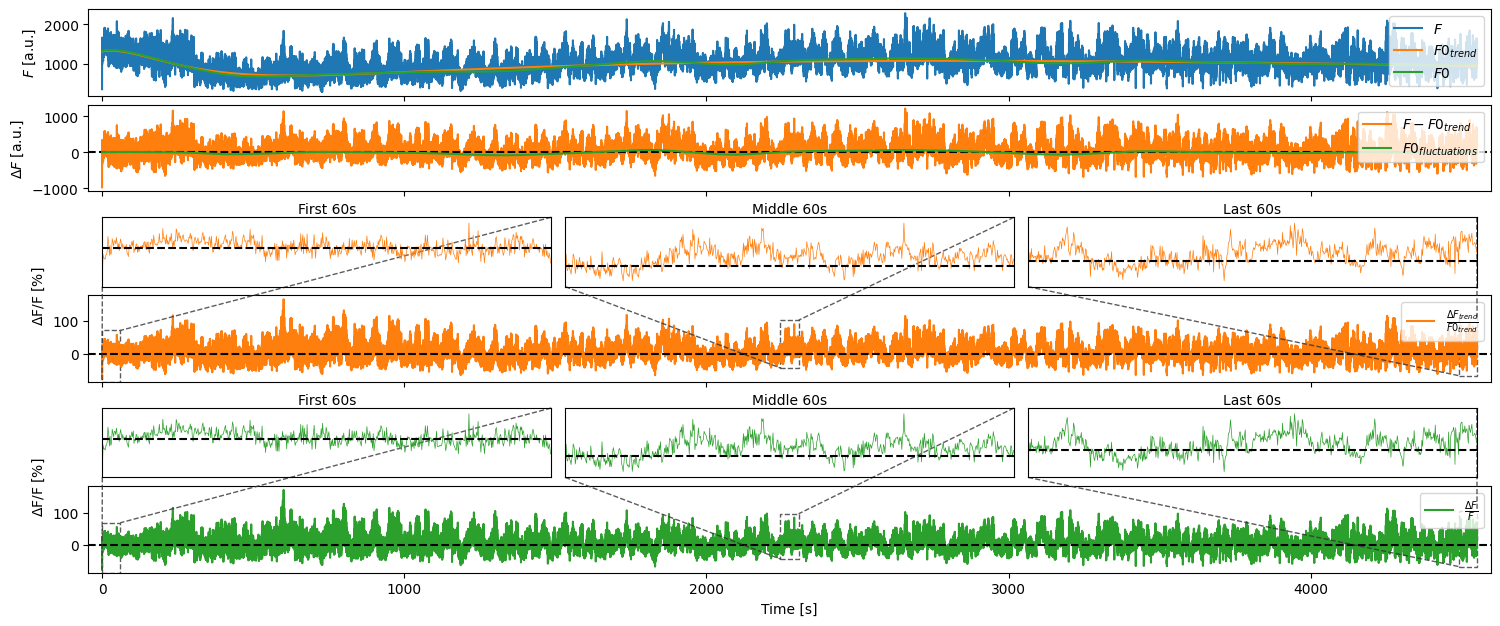

model

numpy  Time=13.5317s  Losses=17046.75, 16307.06 [  813.75  4287.25  6465.88 10098.03  1516.74   568.65   913.31] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax32  Time= 1.0234s  Losses=17030.60, 16318.20 [ 618.43 1348.65 5992.75 6488.29 3395.99  536.5   774.62] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax64  Time= 5.6677s  Losses=17383.21, 16308.27 [   862.02  30879.07 318190.38 348465.4    1026.67    784.72    805.71] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


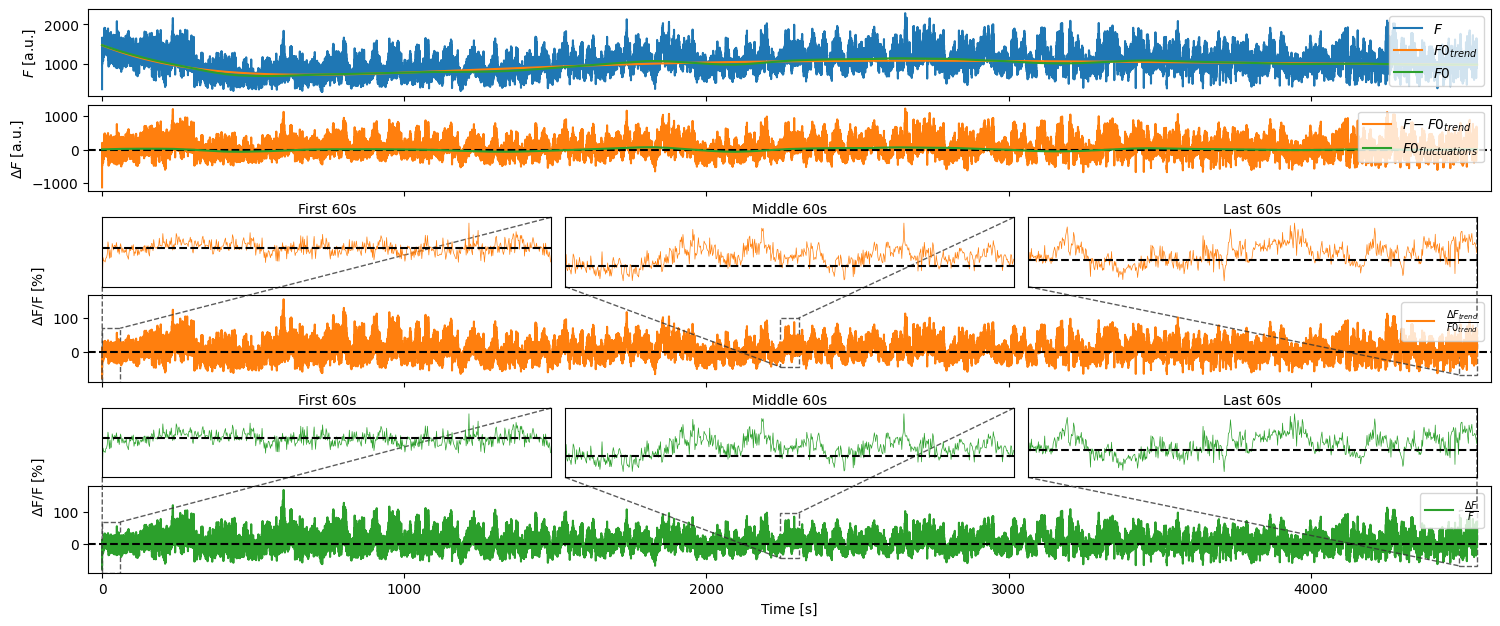

log_model



/tmp/ipykernel_7908/558186901.py:19: RuntimeWarning: overflow encountered in exp
  t_slow, t_fast, t_bright = xp.exp(params[4:])


numpy  Time=11.7631s  Losses=17401.40, 16319.10 [ 1038.19    12.59 11072.35 10602.66   420.31   409.24   459.76] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax32  Time= 1.7067s  Losses=18634.28, 16362.44 [1.14e+03 1.29e+00 2.28e+04 2.24e+04 3.08e+02 5.06e+02 5.42e+02] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax64  Time= 3.5895s  Losses=17399.29, 16319.65 [ 1038.12    37.69 25500.78 25056.27   439.71   423.03   444.68] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


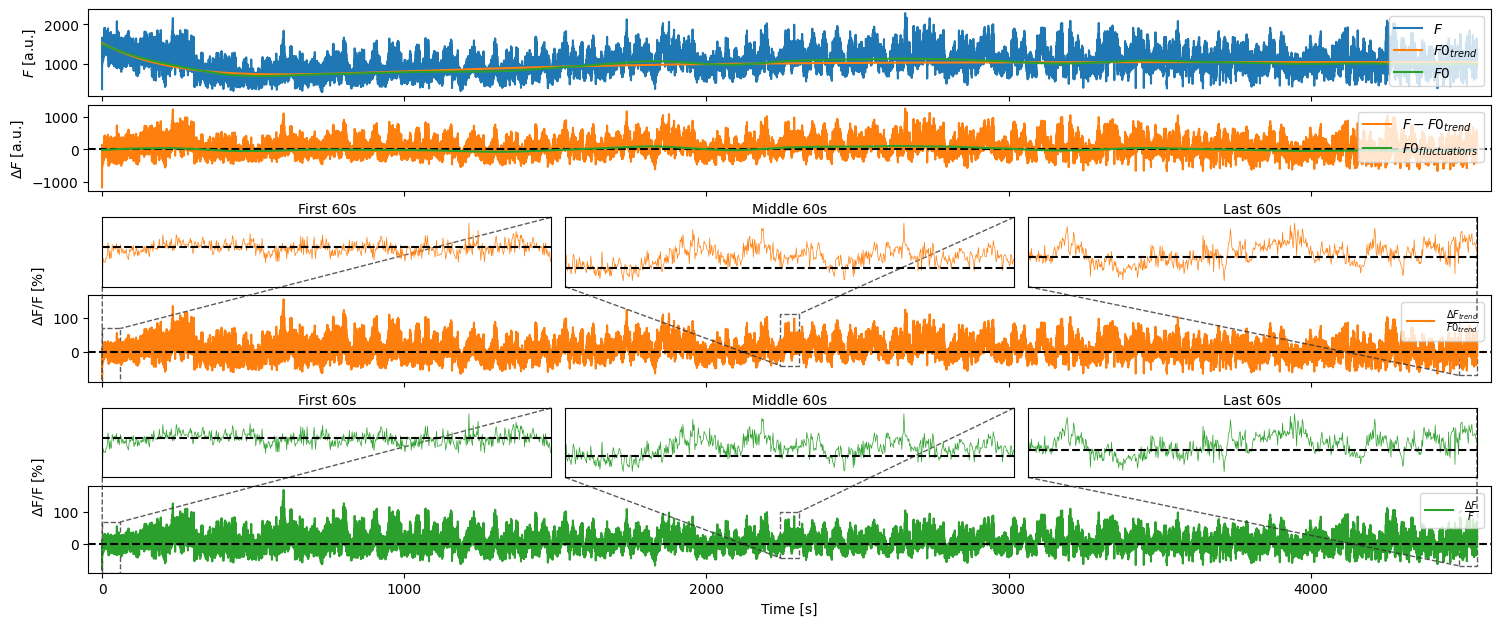

In [12]:
M = AsymmetricTukeyBiweight(2, 3)
bounds = [(0, None)] * 4 + [(300, None), (1, 1200), (1, None)]

for m, x0 in ((old_model, [trace[-1000:].mean(), 0.35, 0.2, 0.99, 3600, 240, 2000]),
                (model, [trace[-1000:].mean(), 350, 200, 10, 3600, 240, 2000]),
                (log_model, [trace[-1000:].mean(), 350, 200, 10, np.log(3600), np.log(240), np.log(2000)])):
    print(f"{m.__name__}\n")
    b = np.array(bounds.copy())
    if m.__name__ == "log_model":
        def log_bound(b):
            return None if b is None else np.log(b)
        b[4:] = [(log_bound(lo), log_bound(hi)) for lo, hi in b[4:]]
    for method in ("numpy", "jax32", "jax64"):
        dtype = jnp.float32 if method[-2:] == "32" else jnp.float64
        backend = "jax" if method[:3] == "jax" else method
        t0 = perf_counter()
        F0, F0trend, res, info = fit_baseline(trace, timestamps, m, x0, b, M=M, backend=backend, dtype=dtype)
        ls = info['lowess_sigma']*F0trend
        loss = np.mean(M.rho((trace - F0) / ls) * ls**2)
        if m.__name__ == "log_model":
            res.x[4:] = np.exp(res.x[4:])
        with np.printoptions(precision=2, suppress=False, linewidth=120):
            print(f"{method}  Time={perf_counter()-t0:7.4f}s  "
                  f"Losses={res.fun/trace.size*res.sigma**2:.2f}, {loss:.2f}", res.x, res.message)
    plot_dff(trace, F0, F0trend, t=timestamps, zoom_duration=60.0)
    plt.show()

#### provide estimate of $\sigma$

old_model

numpy  Time=15.1314s  Losses=7617.15, 7128.59 [6.26e+02 2.04e+00 2.53e+01 9.27e-01 3.57e+03 1.47e+02 1.97e+03] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax32  Time= 0.8643s  Losses=7831.27, 7393.02 [1.09e+03 0.00e+00 2.32e+00 6.32e-01 3.60e+03 2.40e+02 2.00e+03] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax64  Time= 8.7126s  Losses=7621.01, 7224.13 [4.65e+00 2.53e+03 2.19e+04 9.89e-01 3.28e+03 1.50e+02 1.40e+04] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


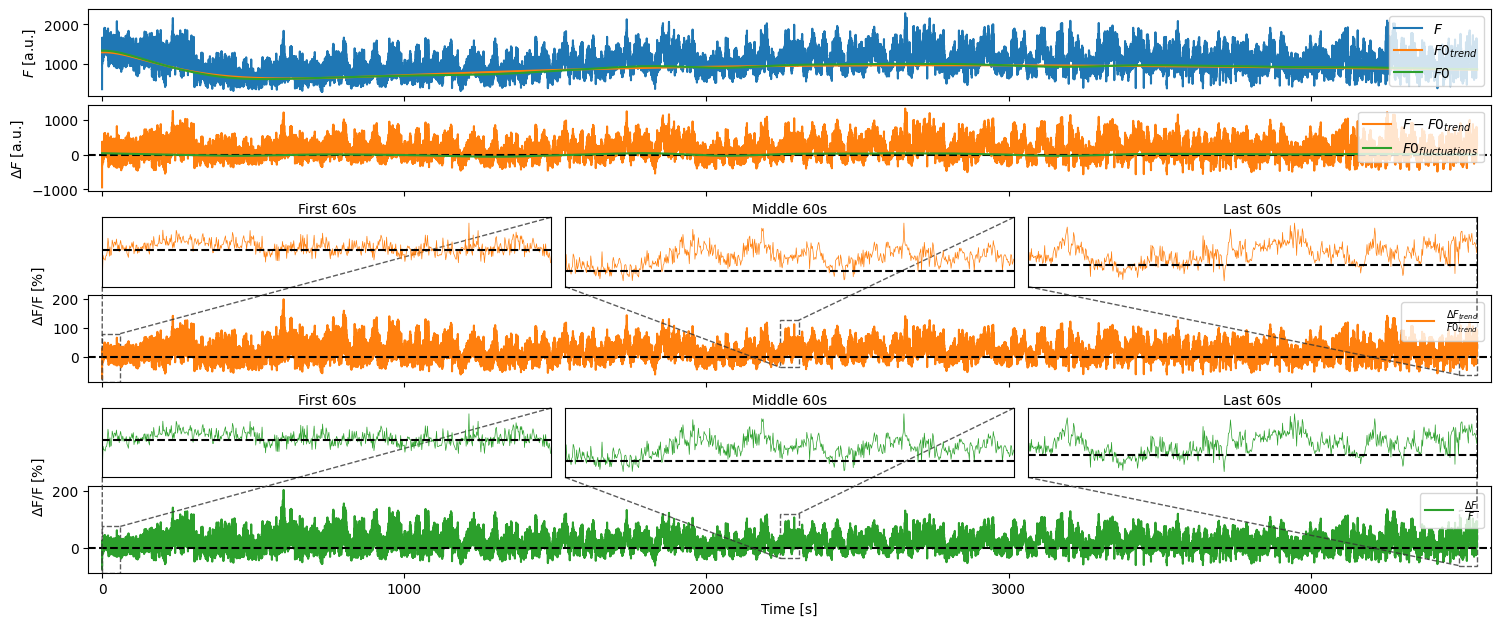

model

numpy  Time=16.3271s  Losses=7620.34, 7136.70 [  835.77  4230.04  6445.56 10100.4   1166.66   518.47   796.93] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax32  Time= 1.0083s  Losses=7618.96, 7140.03 [ 727.88  693.4  6195.21 6200.22 3123.56  481.9   646.16] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax64  Time= 6.1485s  Losses=7621.32, 7131.93 [   854.37  30861.05 318174.1  348481.8     852.87    683.82    699.55] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


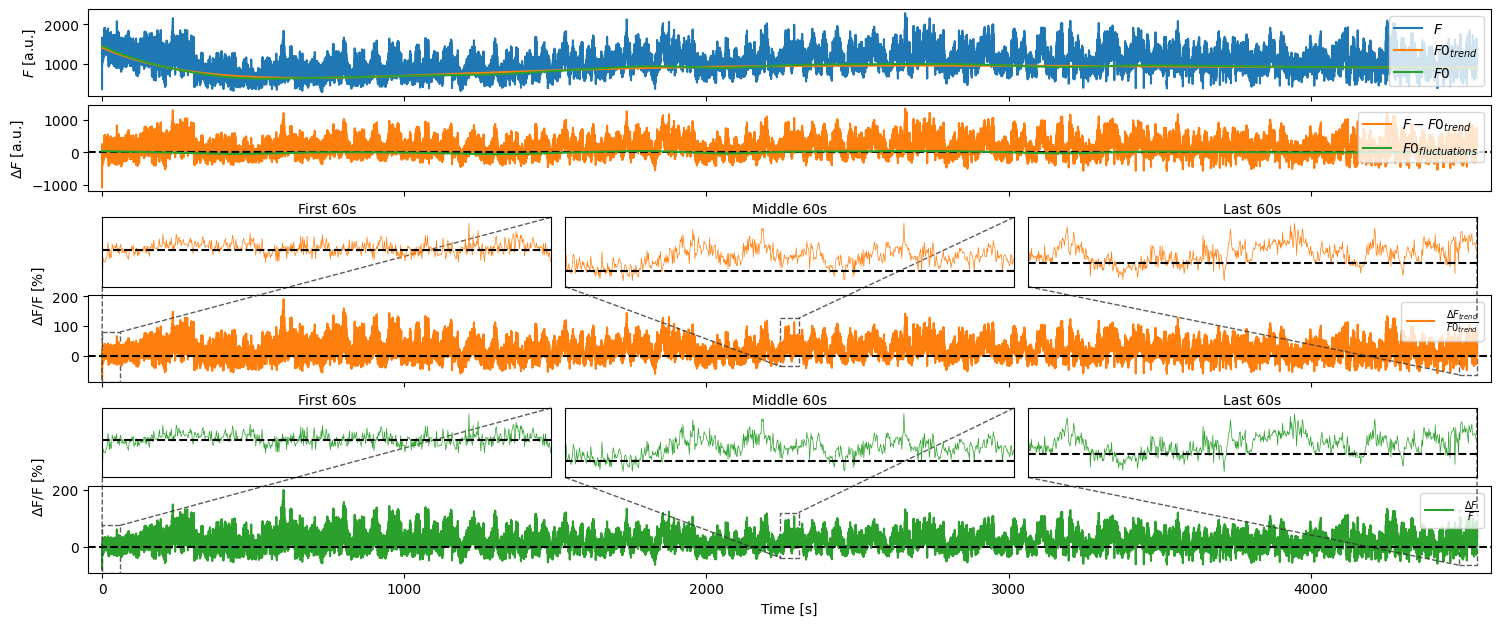

log_model



/tmp/ipykernel_7908/558186901.py:19: RuntimeWarning: overflow encountered in exp
  t_slow, t_fast, t_bright = xp.exp(params[4:])


numpy  Time=16.6947s  Losses=7641.93, 7036.74 [  933.4     42.55 11073.89 10601.03   400.14   400.27   448.24] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax32  Time= 1.5866s  Losses=7641.94, 7036.72 [  933.4    135.47 22768.99 22388.92   300.34   414.77   437.13] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax64  Time= 2.0931s  Losses=7641.85, 7036.12 [  933.34    42.4  25514.96 25042.09   413.37   413.4    433.96] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


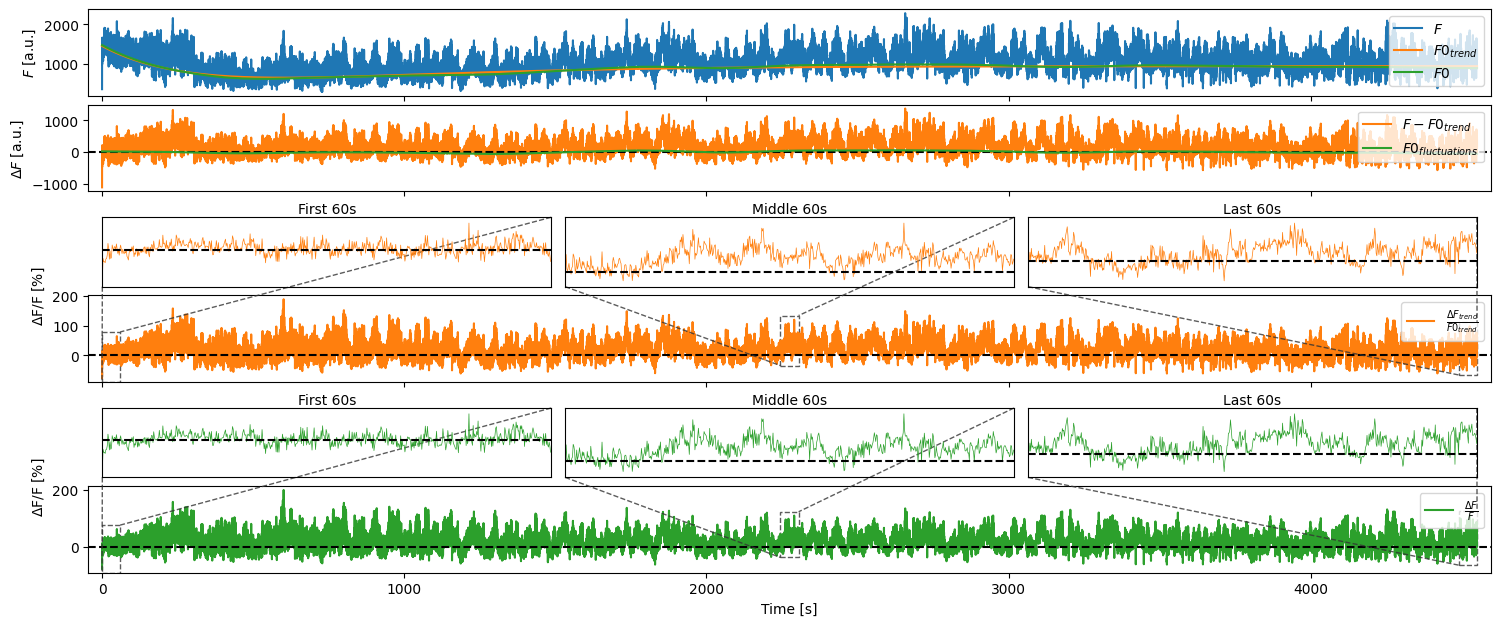

In [13]:
M = AsymmetricTukeyBiweight(2, 3)
bounds = [(0, None)] * 4 + [(300, None), (1, 1200), (1, None)]

for m, x0 in ((old_model, [trace[-1000:].mean(), 0.35, 0.2, 0.99, 3600, 240, 2000]),
                (model, [trace[-1000:].mean(), 350, 200, 10, 3600, 240, 2000]),
                (log_model, [trace[-1000:].mean(), 350, 200, 10, np.log(3600), np.log(240), np.log(2000)])):
    print(f"{m.__name__}\n")
    b = np.array(bounds.copy())
    if m.__name__ == "log_model":
        def log_bound(b):
            return None if b is None else np.log(b)
        b[4:] = [(log_bound(lo), log_bound(hi)) for lo, hi in b[4:]]
    for method in ("numpy", "jax32", "jax64"):
        dtype = jnp.float32 if method[-2:] == "32" else jnp.float64
        backend = "jax" if method[:3] == "jax" else method
        t0 = perf_counter()
        F0, F0trend, res, info = fit_baseline(trace, timestamps, m, x0, b, M=M, fixed_sigma=noise_std(trace), backend=backend, dtype=dtype)
        ls = info['lowess_sigma']*F0trend
        loss = np.mean(M.rho((trace - F0) / ls) * ls**2)
        if m.__name__ == "log_model":
            res.x[4:] = np.exp(res.x[4:])
        with np.printoptions(precision=2, suppress=False, linewidth=120):
            print(f"{method}  Time={perf_counter()-t0:7.4f}s  "
                  f"Losses={res.fun/trace.size*res.sigma**2:.2f}, {loss:.2f}", res.x, res.message)
    plot_dff(trace, F0, F0trend, t=timestamps, zoom_duration=60.0)
    plt.show()

#### multiple traces in parallel

In [14]:
x0 = [trace[-1000:].mean(), 350, 200, 10, 3600, 240, 2000]
n_jobs = min(len(traces[0]), int(os.getenv("CO_CPUS", -1)))

for method in ("numpy", "np_jac", "jax32", "jax64"):
    dtype = jnp.float32 if method[-2:] == "32" else jnp.float64
    backend = "jax" if method[:3] == "jax" else "numpy"
    m = model_jac if method == "np_jac" else model
    t0 = perf_counter()
    res = Parallel(n_jobs=n_jobs)(
                delayed(fit_baseline)(
                    t, timestamps, m, x0, bounds=bounds,
                    M=AsymmetricTukeyBiweight(2, 3),
                    backend=backend, dtype=dtype)
                for t in traces[0]
            )
    losses_trend = [r[2].fun/trace.size*r[2].sigma**2 for r in res]
    losses = [np.mean(M.rho((trace - F0) / (ls:=r[3]['lowess_sigma']*r[1])) * ls**2) for r in res]
    with np.printoptions(precision=2, suppress=False, linewidth=120):
        print(f"{method:6}  Time={perf_counter()-t0:7.4f}s  "
              f"Losses={np.mean(losses_trend):.2f}, {np.mean(losses):.2f}")

numpy   Time=91.6668s  Losses=14906.28, 11241.81


/root/capsule/code/dev.py:583: RuntimeWarning: overflow encountered in multiply
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:583: RuntimeWarning: invalid value encountered in multiply
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:583: RuntimeWarning: overflow encountered in matmul
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:583: RuntimeWarning: overflow encountered in multiply
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:583: RuntimeWarning: invalid value encountered in multiply
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:583: RuntimeWarning: overflow encountered in matmul
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:583: RuntimeWarning: invalid value encountered in matmul
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:583: RuntimeWarning: overflow encountered in multiply
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:583: RuntimeWarning: 

np_jac  Time=108.4677s  Losses=15541.90, 11242.97
jax32   Time=31.5356s  Losses=15159.46, 11246.70


/opt/conda/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


jax64   Time=70.2810s  Losses=15628.42, 11242.73
